# Figure 2 — Dwell / Ramp Domain Validation

Notebook version of `02_build_figure2_dwell_ramp_validation.py`.

This notebook preserves the validated diagnostic structure and canonical v6.1 preprocessing:
- Air is **not** isotonic-constrained.
- No local artifact bridging is applied.
- The small SG-induced Air β = 5 negative DTG excursion is retained as generated.
- 80%, 90%, and 95% sustained ramp-onset thresholds are evaluated.
- The 90% threshold remains the canonical display-domain reference.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# In a notebook, __file__ is unavailable. Use the notebook working directory.
CODE_DIR = Path.cwd()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from alc_core import (
    BETAS, RESULTS_DIR, FIG_MAIN_DIR, canonical_clean_curve,
    load_raw_curve, rolling_temperature_slope, stable_ramp_onset, save_figure,
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_MAIN_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
THRESHOLDS = (0.80, 0.90, 0.95)
PRIMARY_THRESHOLD = 0.90
DWELL_END_S = 1800.0

COLORS = {5: "#1f77b4", 10: "#d95f02", 20: "#2ca02c"}
MARKERS = {0.80: "v", 0.90: "o", 0.95: "^"}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 9.2,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


In [3]:
def dwell_rate(raw: pd.DataFrame) -> pd.DataFrame:
    dwell = raw[raw.time_s <= DWELL_END_S].copy()
    t = dwell.time_s.to_numpy(float)
    m = dwell.mass_pct.to_numpy(float)

    dt = float(np.median(np.diff(t)))
    points = max(5, int(round(60.0 / dt)) + 1)
    if points % 2 == 0:
        points += 1
    if points >= len(m):
        points = len(m) - 1 if len(m) % 2 == 0 else len(m)
    if points <= 3:
        points = 5

    smooth = savgol_filter(m, window_length=points, polyorder=3, mode="interp")
    return pd.DataFrame({
        "time_s": t,
        "mass_loss_rate_pct_s": -np.gradient(smooth, t),
    })


## Build canonical curves and onset/sensitivity tables

In [4]:
raw_curves, clean_curves = {}, {}
dwell_curves, transition_curves = {}, {}
onset_rows, sensitivity_rows = [], []

for atm in ("N2", "Air"):
    for beta in BETAS:
        raw = load_raw_curve(atm, beta)
        clean, _ = canonical_clean_curve(atm, beta)

        raw_curves[(atm, beta)] = raw
        clean_curves[(atm, beta)] = clean
        dwell_curves[(atm, beta)] = dwell_rate(raw)

        slope = rolling_temperature_slope(raw, 60.0)
        transition_curves[(atm, beta)] = pd.DataFrame({
            "time_s": raw.time_s.to_numpy(float),
            "temperature_K": raw.temp_K.to_numpy(float),
            "normalized_dTdt": slope / (beta / 60.0),
        })

        for threshold in THRESHOLDS:
            onset = stable_ramp_onset(
                raw, beta,
                fraction=threshold,
                min_duration_s=60.0,
            )

            onset_rows.append({
                "atmosphere": atm,
                "beta_C_per_min": beta,
                "threshold_fraction_nominal": threshold,
                "onset_time_s": onset["onset_time_s"],
                "onset_temperature_K": onset["onset_temperature_K"],
                "normalized_rate_at_onset": onset["normalized_rate"],
                "verified_duration_s": onset["verified_duration_s"],
                "slope_window_s": 60.0,
                "required_sustained_s": 60.0,
            })

            ramp = clean[clean.temperature_K >= onset["onset_temperature_K"]]
            peak_region = ramp[
                (ramp.temperature_K >= max(350.0, onset["onset_temperature_K"] + 20.0))
                & (ramp.temperature_K <= 1000.0)
            ]
            peak = peak_region.loc[peak_region.dtg_pct_per_K.idxmax()]
            integrated = float(np.trapezoid(
                ramp.dtg_pct_per_K.to_numpy(),
                ramp.temperature_K.to_numpy(),
            ))

            sensitivity_rows.append({
                "atmosphere": atm,
                "beta_C_per_min": beta,
                "threshold_fraction_nominal": threshold,
                "onset_time_s": onset["onset_time_s"],
                "onset_temperature_K": onset["onset_temperature_K"],
                "principal_peak_temperature_K": float(peak.temperature_K),
                "principal_peak_dtg_pct_per_K": float(peak.dtg_pct_per_K),
                "integrated_ramp_mass_loss_pct": integrated,
            })


In [5]:
onset_df = pd.DataFrame(onset_rows)
sens_df = pd.DataFrame(sensitivity_rows)

ref = (
    sens_df[sens_df.threshold_fraction_nominal == PRIMARY_THRESHOLD][[
        "atmosphere", "beta_C_per_min", "onset_temperature_K",
        "principal_peak_temperature_K", "principal_peak_dtg_pct_per_K",
        "integrated_ramp_mass_loss_pct",
    ]]
    .rename(columns={
        "onset_temperature_K": "onset_temperature_K_ref90",
        "principal_peak_temperature_K": "peak_temperature_K_ref90",
        "principal_peak_dtg_pct_per_K": "peak_dtg_ref90",
        "integrated_ramp_mass_loss_pct": "integrated_loss_ref90",
    })
)

sens_df = sens_df.merge(ref, on=["atmosphere", "beta_C_per_min"], how="left")
sens_df["delta_onset_temperature_vs_90_K"] = (
    sens_df.onset_temperature_K - sens_df.onset_temperature_K_ref90
)
sens_df["delta_peak_temperature_vs_90_K"] = (
    sens_df.principal_peak_temperature_K - sens_df.peak_temperature_K_ref90
)
sens_df["delta_peak_height_relative_pct_vs_90"] = (
    100.0 * (sens_df.principal_peak_dtg_pct_per_K - sens_df.peak_dtg_ref90)
    / sens_df.peak_dtg_ref90
)
sens_df["delta_integrated_loss_vs_90_pct_point"] = (
    sens_df.integrated_ramp_mass_loss_pct - sens_df.integrated_loss_ref90
)

onset_df.to_csv(RESULTS_DIR / "Figure2_Ramp_Onset_Sensitivity.csv", index=False)
sens_df.to_csv(RESULTS_DIR / "Figure2_Threshold_Sensitivity.csv", index=False)

display(onset_df)
display(sens_df)


,atmosphere,beta_C_per_min,threshold_fraction_nominal,onset_time_s,onset_temperature_K,normalized_rate_at_onset,verified_duration_s,slope_window_s,required_sustained_s
0,N2,5,0.80,1834.0,326.352,0.810257,70.0,60.0,60.0
1,N2,5,0.90,1862.0,328.482,0.929829,70.0,60.0,60.0
2,N2,5,0.95,2044.0,342.838,0.953743,70.0,60.0,60.0
3,N2,10,0.80,1824.0,327.105,0.812545,64.0,60.0,60.0
4,N2,10,0.90,1832.0,328.335,0.901795,64.0,60.0,60.0
5,N2,10,0.95,1856.0,332.125,0.952339,64.0,60.0,60.0
6,N2,20,0.80,1820.0,329.479,0.803664,60.0,60.0,60.0
7,N2,20,0.90,1830.0,332.797,0.940549,60.0,60.0,60.0
8,N2,20,0.95,1835.0,334.457,0.971037,60.0,60.0,60.0
9,Air,5,0.80,1834.0,326.264,0.804600,70.0,60.0,60.0


,atmosphere,beta_C_per_min,threshold_fraction_nominal,onset_time_s,onset_temperature_K,principal_peak_temperature_K,principal_peak_dtg_pct_per_K,integrated_ramp_mass_loss_pct,onset_temperature_K_ref90,peak_temperature_K_ref90,peak_dtg_ref90,integrated_loss_ref90,delta_onset_temperature_vs_90_K,delta_peak_temperature_vs_90_K,delta_peak_height_relative_pct_vs_90,delta_integrated_loss_vs_90_pct_point
0,N2,5,0.80,1834.0,326.352,720.0,0.286305,88.464604,328.482,720.0,0.286305,86.983477,-2.130,0.0,0.0,1.481127
1,N2,5,0.90,1862.0,328.482,720.0,0.286305,86.983477,328.482,720.0,0.286305,86.983477,0.000,0.0,0.0,0.000000
2,N2,5,0.95,2044.0,342.838,720.0,0.286305,86.742018,328.482,720.0,0.286305,86.983477,14.356,0.0,0.0,-0.241459
3,N2,10,0.80,1824.0,327.105,734.0,0.312183,87.507136,328.335,734.0,0.312183,87.046355,-1.230,0.0,0.0,0.460781
4,N2,10,0.90,1832.0,328.335,734.0,0.312183,87.046355,328.335,734.0,0.312183,87.046355,0.000,0.0,0.0,0.000000
5,N2,10,0.95,1856.0,332.125,734.0,0.312183,86.929250,328.335,734.0,0.312183,87.046355,3.790,0.0,0.0,-0.117105
6,N2,20,0.80,1820.0,329.479,746.0,0.324510,86.712241,332.797,746.0,0.324510,86.712241,-3.318,0.0,0.0,0.000000
7,N2,20,0.90,1830.0,332.797,746.0,0.324510,86.712241,332.797,746.0,0.324510,86.712241,0.000,0.0,0.0,0.000000
8,N2,20,0.95,1835.0,334.457,746.0,0.324510,86.712241,332.797,746.0,0.324510,86.712241,1.660,0.0,0.0,0.000000
9,Air,5,0.80,1834.0,326.264,677.0,0.594473,90.731468,328.364,677.0,0.594473,89.137151,-2.100,0.0,0.0,1.594317


## Generate Figure 2

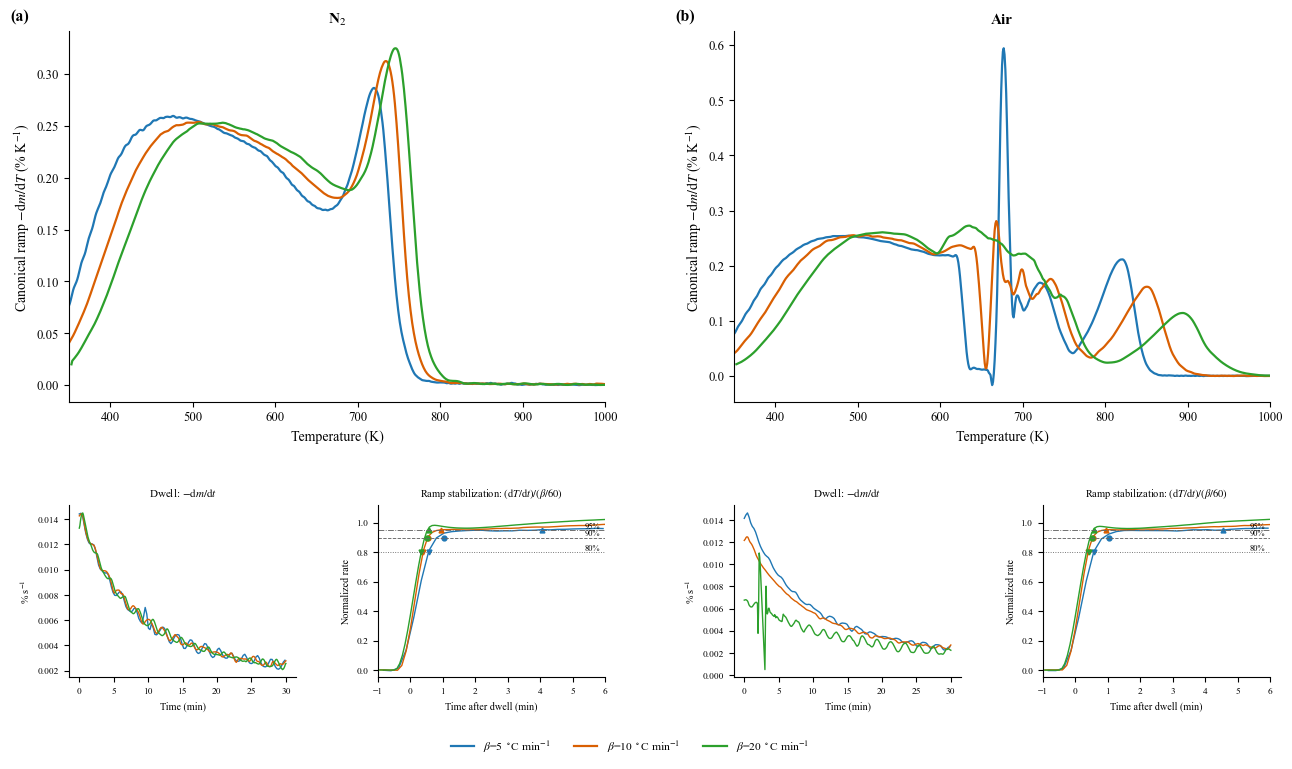

In [6]:
fig = plt.figure(figsize=(13.2, 7.6))
outer = fig.add_gridspec(1, 2, wspace=0.24)
main_axes = []

for panel, atm in enumerate(("N2", "Air")):
    group = outer[0, panel].subgridspec(
        2, 2, height_ratios=(2.15, 1.0), hspace=0.38, wspace=0.36
    )
    ax = fig.add_subplot(group[0, :])
    dwell_ax = fig.add_subplot(group[1, 0])
    rate_ax = fig.add_subplot(group[1, 1])
    main_axes.append(ax)

    # Main canonical ramp DTG
    for beta in BETAS:
        onset90 = float(onset_df[
            (onset_df.atmosphere == atm)
            & (onset_df.beta_C_per_min == beta)
            & (onset_df.threshold_fraction_nominal == 0.90)
        ].onset_temperature_K.iloc[0])

        curve = clean_curves[(atm, beta)]
        ramp = curve[curve.temperature_K >= max(350.0, onset90 + 20.0)]
        ax.plot(
            ramp.temperature_K, ramp.dtg_pct_per_K,
            color=COLORS[beta], lw=1.6,
            label=rf"$\beta$={beta} $^\circ$C min$^{{-1}}$",
        )

    ax.set_xlim(350, 1000)
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel(r"Canonical ramp $-\mathrm{d}m/\mathrm{d}T$ (% K$^{-1}$)")
    ax.set_title("N$_2$" if atm == "N2" else "Air", fontweight="bold")
    ax.text(
        -0.11, 1.03, f"({chr(97 + panel)})",
        transform=ax.transAxes, fontsize=11.5, fontweight="bold",
    )

    # Dwell domain
    for beta in BETAS:
        dwell = dwell_curves[(atm, beta)]
        dwell_ax.plot(
            dwell.time_s / 60.0,
            dwell.mass_loss_rate_pct_s,
            color=COLORS[beta], lw=1.0,
        )

    dwell_ax.set_title(r"Dwell: $-\mathrm{d}m/\mathrm{d}t$", fontsize=8)
    dwell_ax.set_xlabel("Time (min)", fontsize=7.3)
    dwell_ax.set_ylabel(r"% s$^{-1}$", fontsize=7.3)
    dwell_ax.tick_params(labelsize=6.8)

    # Ramp stabilization
    for beta in BETAS:
        rate = transition_curves[(atm, beta)]
        mask = (rate.time_s >= 1740.0) & (rate.time_s <= 2160.0)

        rate_ax.plot(
            (rate.loc[mask, "time_s"] - DWELL_END_S) / 60.0,
            rate.loc[mask, "normalized_dTdt"],
            color=COLORS[beta], lw=1.0,
        )

        for threshold in THRESHOLDS:
            rec = onset_df[
                (onset_df.atmosphere == atm)
                & (onset_df.beta_C_per_min == beta)
                & (onset_df.threshold_fraction_nominal == threshold)
            ].iloc[0]

            rate_ax.plot(
                (rec.onset_time_s - DWELL_END_S) / 60.0,
                threshold,
                marker=MARKERS[threshold],
                color=COLORS[beta],
                ms=3.5,
                linestyle="none",
            )

    for threshold, ls in zip(THRESHOLDS, (":", "--", "-.")):
        rate_ax.axhline(threshold, color="0.4", lw=0.65, ls=ls)
        rate_ax.text(
            5.85, threshold + 0.015,
            f"{int(threshold * 100)}%",
            fontsize=6.2, ha="right",
        )

    rate_ax.set_xlim(-1.0, 6.0)
    rate_ax.set_ylim(-0.05, 1.12)
    rate_ax.set_title(
        r"Ramp stabilization: $(\mathrm{d}T/\mathrm{d}t)/(\beta/60)$",
        fontsize=7.5,
    )
    rate_ax.set_xlabel("Time after dwell (min)", fontsize=7.3)
    rate_ax.set_ylabel("Normalized rate", fontsize=7.3)
    rate_ax.tick_params(labelsize=6.8)

    for a in (ax, dwell_ax, rate_ax):
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

handles, labels = main_axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=3, frameon=False,
    bbox_to_anchor=(0.5, 0.005), fontsize=8.4,
)
fig.subplots_adjust(left=0.075, right=0.985, top=0.97, bottom=0.12)

plt.show()


## Save Figure 2

In [7]:
# Re-create/save the current figure if needed.
# If the previous cell was just executed, `fig` is still available.

save_figure(
    fig,
    FIG_MAIN_DIR / "Figure2_dwell_ramp_domain_validation.png",
    FIG_MAIN_DIR / "Figure2_dwell_ramp_domain_validation.pdf",
    dpi=400,
)

print("Wrote Figure2_dwell_ramp_domain_validation.png / .pdf")


Wrote Figure2_dwell_ramp_domain_validation.png / .pdf


## Scientific QA

In [8]:
# Explicitly verify the known Air β=5 smoothing wiggle is kinetically immaterial.
air5 = clean_curves[("Air", 5)]
zone = air5[(air5.temperature_K >= 661) & (air5.temperature_K <= 664)]

print("Air beta=5 SG wiggle (canonical, unmodified):")
display(zone)

print("\nRamp-onset sensitivity:")
display(onset_df)


Air beta=5 SG wiggle (canonical, unmodified):


,temperature_K,mass_clean_pct,dtg_pct_per_K
338,661.0,27.640102,0.001524
339,662.0,27.640786,-0.008447
340,663.0,27.656995,-0.016643
341,664.0,27.674071,-0.011044



Ramp-onset sensitivity:


,atmosphere,beta_C_per_min,threshold_fraction_nominal,onset_time_s,onset_temperature_K,normalized_rate_at_onset,verified_duration_s,slope_window_s,required_sustained_s
0,N2,5,0.80,1834.0,326.352,0.810257,70.0,60.0,60.0
1,N2,5,0.90,1862.0,328.482,0.929829,70.0,60.0,60.0
2,N2,5,0.95,2044.0,342.838,0.953743,70.0,60.0,60.0
3,N2,10,0.80,1824.0,327.105,0.812545,64.0,60.0,60.0
4,N2,10,0.90,1832.0,328.335,0.901795,64.0,60.0,60.0
5,N2,10,0.95,1856.0,332.125,0.952339,64.0,60.0,60.0
6,N2,20,0.80,1820.0,329.479,0.803664,60.0,60.0,60.0
7,N2,20,0.90,1830.0,332.797,0.940549,60.0,60.0,60.0
8,N2,20,0.95,1835.0,334.457,0.971037,60.0,60.0,60.0
9,Air,5,0.80,1834.0,326.264,0.804600,70.0,60.0,60.0
